In [2]:
import os
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import gensim.downloader as api
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["DATASETS_DISABLE_PROGRESS_BARS"] = "1"

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)

from transformers.utils import logging as transformers_logging
transformers_logging.set_verbosity_error()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="warmup_ratio is deprecated")
warnings.filterwarnings("ignore", message="There were missing keys")
warnings.filterwarnings("ignore", message="There were unexpected keys")

In [3]:
bbc = load_files("./bbc", encoding="latin-1", decode_error="replace")
df = pd.DataFrame({'text': bbc.data, 'category_id': bbc.target})
df['category_name'] = df['category_id'].map(lambda x: bbc.target_names[x])

print(f"acount{len(df)}")
print(df['category_name'].value_counts())
df.head()

acount2225
category_name
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


,text,category_id,category_name
0,Tate & Lyle boss bags top award\n\nTate & Lyle...,0,business
1,Halo 2 sells five million copies\n\nMicrosoft ...,4,tech
2,MSPs hear renewed climate warning\n\nClimate c...,2,politics
3,Pavey focuses on indoor success\n\nJo Pavey wi...,3,sport
4,Tories reject rethink on axed MP\n\nSacked MP ...,2,politics


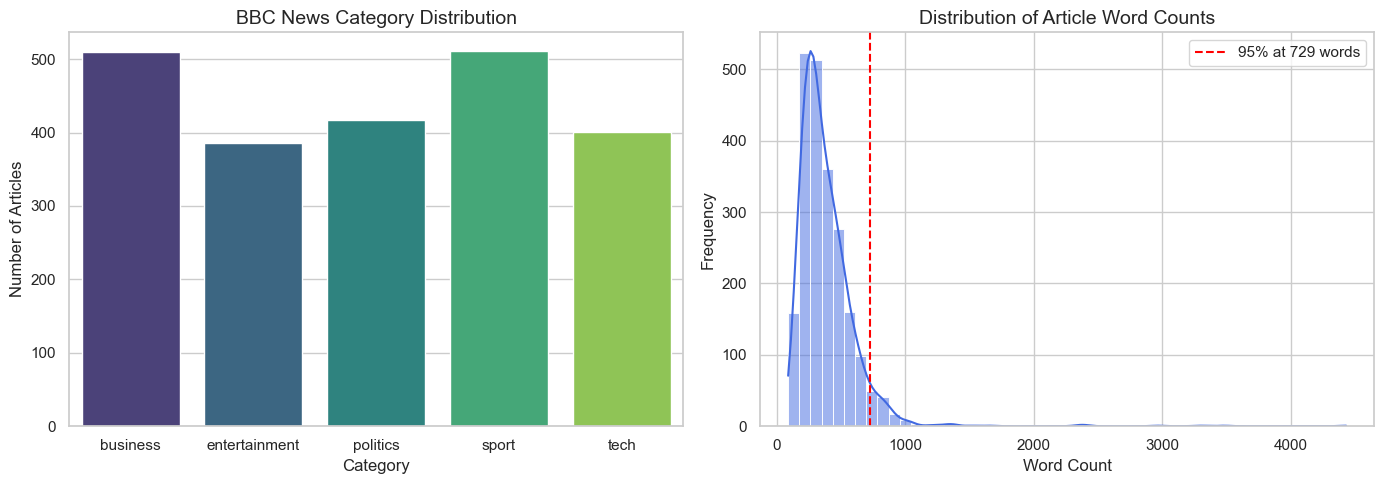

count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64


In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='category_name', palette='viridis', order=bbc.target_names)
plt.title('BBC News Category Distribution', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Articles')


df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='word_count', bins=50, kde=True, color='royalblue')
plt.title('Distribution of Article Word Counts', fontsize=14)
plt.xlabel('Word Count')
plt.ylabel('Frequency')

quantile_95 = df['word_count'].quantile(0.95)
plt.axvline(x=quantile_95, color='red', linestyle='--', label=f'95% at {int(quantile_95)} words')
plt.legend()

plt.tight_layout()
plt.show()

print(df['word_count'].describe())

In [5]:
nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text, strategy='classical'):
  
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    if strategy == 'classical':
        tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    elif strategy == 'word2vec':
        pass 
        
    return " ".join(tokens)

df['clean_text_classical'] = df['text'].apply(lambda x: preprocess_text(x, 'classical'))

df['clean_text_w2v'] = df['text'].apply(lambda x: preprocess_text(x, 'word2vec'))

display(df[['text', 'clean_text_classical', 'clean_text_w2v']].head(2))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,text,clean_text_classical,clean_text_w2v
0,Tate & Lyle boss bags top award\n\nTate & Lyle...,tate lyle boss bag top award tate lyle chief e...,tate lyle boss bags top award tate lyle s chie...
1,Halo 2 sells five million copies\n\nMicrosoft ...,halo sell five million copi microsoft celebr b...,halo sells five million copies microsoft is ce...


In [12]:
X_train_cls, X_test_cls, y_train, y_test = train_test_split(
    df['clean_text_classical'], df['category_id'], test_size=0.2, random_state=42, stratify=df['category_id']
)
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    df['clean_text_w2v'], df['category_id'], test_size=0.2, random_state=42, stratify=df['category_id']
)
X_train_raw, X_test_raw, _, _ = train_test_split(
    df['text'], df['category_id'], test_size=0.2, random_state=42, stratify=df['category_id']
)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(max_iter=1000, dual=False),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

# Method A: Bag-of-Words & TF-IDF
print(" Train Method A (Bag-of-Words / TF-IDF)...")
vectorizers = {
    'BoW': CountVectorizer(min_df=2, max_df=0.8, ngram_range=(1, 2), max_features=10000),
    'TF-IDF': TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1, 2), max_features=10000)
}

for vec_name, vec in vectorizers.items():
    X_train_vec = vec.fit_transform(X_train_cls)
    X_test_vec = vec.transform(X_test_cls)
    
    for clf_name, clf in classifiers.items():
       
        start_time = time.time()
        clf.fit(X_train_vec, y_train)
        train_time = time.time() - start_time
        
        start_pred = time.time()
        preds = clf.predict(X_test_vec)
        pred_time = time.time() - start_pred
        
        results[f"{vec_name} + {clf_name}"] = {
            'Accuracy': accuracy_score(y_test, preds),
            'F1-Macro': f1_score(y_test, preds, average='macro'),
            'Train Time (s)': round(train_time, 4),
            'Prediction Time (s)': round(pred_time, 4)
        }

# Method B: Averaged Word2Vec
print("\n Extract Word2Vec features and train method B...")
w2v_model = api.load('word2vec-google-news-300')

def get_w2v_features(texts):
    features = np.zeros((len(texts), 300))
    for i, text in enumerate(texts):
        words = text.split()
        vecs = [w2v_model[w] for w in words if w in w2v_model]
        if vecs:
            features[i] = np.mean(vecs, axis=0)
    return features

X_train_wv_feat = get_w2v_features(X_train_w2v)
X_test_wv_feat = get_w2v_features(X_test_w2v)

for clf_name, clf in classifiers.items():
    start_time = time.time()
    clf.fit(X_train_wv_feat, y_train)
    train_time = time.time() - start_time
    
    start_pred = time.time()
    preds = clf.predict(X_test_wv_feat)
    pred_time = time.time() - start_pred
    
    results[f"Word2Vec + {clf_name}"] = {
        'Accuracy': accuracy_score(y_test, preds),
        'F1-Macro': f1_score(y_test, preds, average='macro'),
        'Train Time (s)': round(train_time, 4),
        'Prediction Time (s)': round(pred_time, 4)
    }

traditional_results_df = pd.DataFrame(results).T.sort_values(by='F1-Macro', ascending=False)
display(traditional_results_df)

 Train Method A (Bag-of-Words / TF-IDF)...

 Extract Word2Vec features and train method B...


,Accuracy,F1-Macro,Train Time (s),Prediction Time (s)
TF-IDF + Linear SVM,0.973034,0.972797,0.1621,0.0010
BoW + Logistic Regression,0.970787,0.970562,0.2341,0.0000
TF-IDF + Logistic Regression,0.970787,0.970298,0.2431,0.0000
BoW + Linear SVM,0.961798,0.961810,7.3571,0.0010
Word2Vec + Linear SVM,0.955056,0.954376,0.0998,0.0010
Word2Vec + Random Forest,0.950562,0.950180,2.4563,0.0120
TF-IDF + Random Forest,0.948315,0.948789,1.4697,0.0406
BoW + Random Forest,0.948315,0.947912,1.3497,0.0401
Word2Vec + Logistic Regression,0.943820,0.942805,0.1015,0.0010


In [7]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
train_dataset = Dataset.from_dict({"text": X_train_raw.tolist(), "label": y_train.tolist()})
test_dataset = Dataset.from_dict({"text": X_test_raw.tolist(), "label": y_test.tolist()})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'Accuracy': accuracy_score(labels, predictions),
        'F1-Macro': f1_score(labels, predictions, average='macro')
    }

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)

total_steps = (len(tokenized_train) // 8) * 4
warmup_steps = int(total_steps * 0.1)

training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=4,                
    per_device_train_batch_size=8,    
    per_device_eval_batch_size=16,
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    optim="adamw_torch",
    eval_strategy="epoch",            
    save_strategy="epoch",
    logging_strategy="epoch",  
    load_best_model_at_end=True,      
    metric_for_best_model="eval_F1-Macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),   
    report_to="none",    
    disable_tqdm=True 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

print("\n Start BERT fine-tuning \n")
start_time = time.time()
train_result = trainer.train()
total_train_time = time.time() - start_time

history = trainer.state.log_history

train_logs = [log for log in history if 'loss' in log and 'epoch' in log]
eval_logs = [log for log in history if 'eval_loss' in log and 'epoch' in log]

table_data = []
last_epoch_time = start_time 

for i in range(len(eval_logs)):
    avg_epoch_time = total_train_time / training_args.num_train_epochs
    
    table_data.append({
        'Epoch': int(eval_logs[i]['epoch']),
        'Training Loss': train_logs[i]['loss'] if i < len(train_logs) else None,
        'Validation Loss': eval_logs[i]['eval_loss'],
        'Accuracy': eval_logs[i]['eval_Accuracy'],
        'F1-Macro': eval_logs[i]['eval_F1-Macro'],
        'Epoch Time (s)': round(avg_epoch_time, 2)  
    })

results_df = pd.DataFrame(table_data)
display(results_df)

Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/445 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


 Start BERT fine-tuning 

{'loss': '0.5247', 'grad_norm': '0.04127', 'learning_rate': '4.179e-05', 'epoch': '1'}
{'eval_loss': '0.2303', 'eval_Accuracy': '0.9506', 'eval_F1-Macro': '0.9505', 'eval_runtime': '1.234', 'eval_samples_per_second': '360.8', 'eval_steps_per_second': '22.7', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.004955', 'grad_norm': '0.01012', 'learning_rate': '2.488e-07', 'epoch': '4'}
{'eval_loss': '0.2556', 'eval_Accuracy': '0.9618', 'eval_F1-Macro': '0.9612', 'eval_runtime': '1.214', 'eval_samples_per_second': '366.5', 'eval_steps_per_second': '23.06', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '100.1', 'train_samples_per_second': '71.1', 'train_steps_per_second': '8.908', 'train_loss': '0.1529', 'epoch': '4'}


,Epoch,Training Loss,Validation Loss,Accuracy,F1-Macro,Epoch Time (s)
0,1,0.524738,0.230251,0.950562,0.950457,25.19
1,2,0.074255,0.290113,0.946067,0.945135,25.19
2,3,0.007777,0.256663,0.964045,0.963415,25.19
3,4,0.004955,0.255634,0.961798,0.961192,25.19


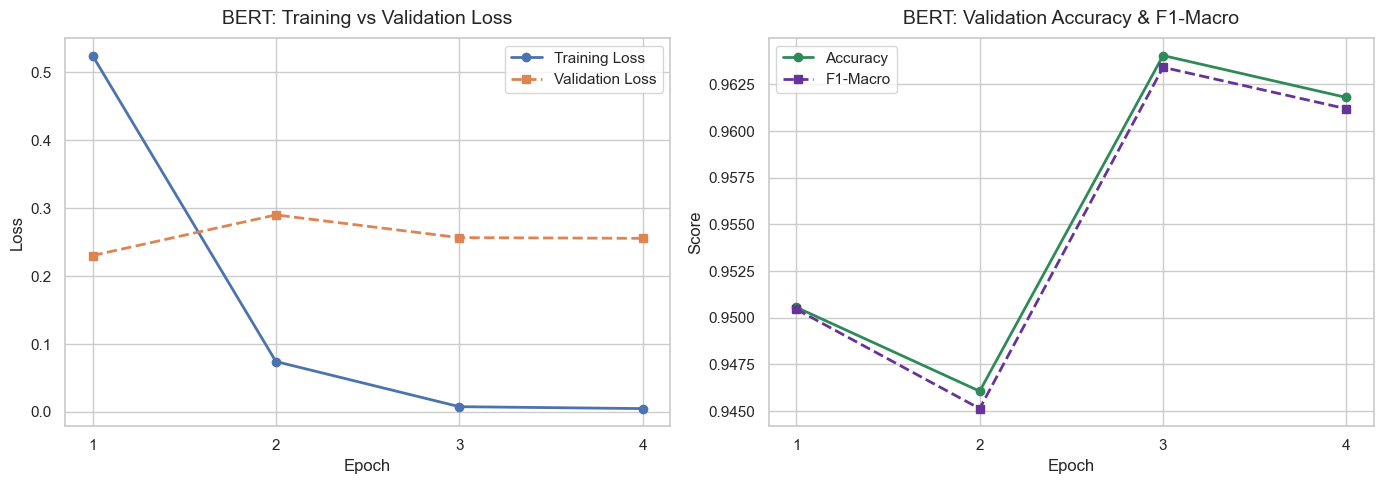

{'eval_loss': '0.2567', 'eval_Accuracy': '0.964', 'eval_F1-Macro': '0.9634', 'eval_runtime': '1.259', 'eval_samples_per_second': '353.5', 'eval_steps_per_second': '22.25', 'epoch': '4'}


In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(results_df['Epoch'], results_df['Training Loss'], marker='o', linestyle='-', linewidth=2, label='Training Loss')
plt.plot(results_df['Epoch'], results_df['Validation Loss'], marker='s', linestyle='--', linewidth=2, label='Validation Loss')
plt.title('BERT: Training vs Validation Loss', fontsize=14, pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(results_df['Epoch'].astype(int))
plt.legend(fontsize=11)

plt.subplot(1, 2, 2)
plt.plot(results_df['Epoch'], results_df['Accuracy'], marker='o', linestyle='-', linewidth=2, color='seagreen', label='Accuracy')
plt.plot(results_df['Epoch'], results_df['F1-Macro'], marker='s', linestyle='--', linewidth=2, color='rebeccapurple', label='F1-Macro')
plt.title('BERT: Validation Accuracy & F1-Macro', fontsize=14, pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(results_df['Epoch'].astype(int))
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

start_pred_time = time.time()
bert_results = trainer.evaluate()
pred_time = time.time() - start_pred_time

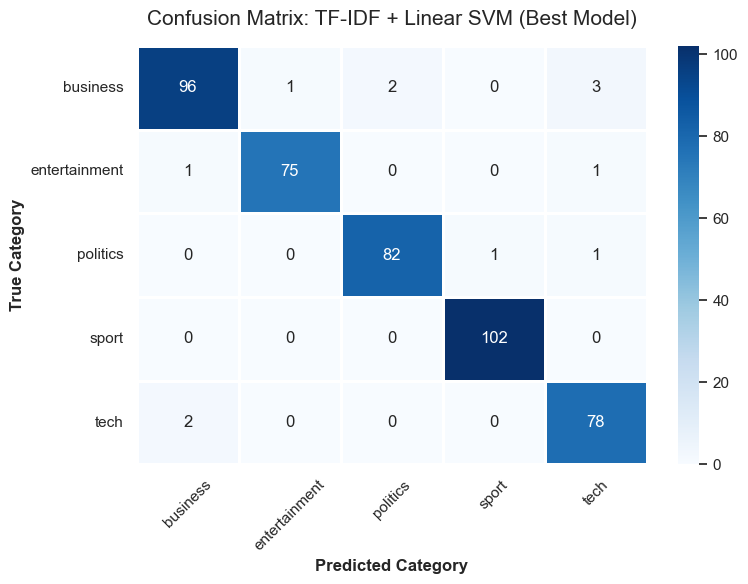

Misclassified Examples

[Misjudgment Record]
   Predicted class by the model : TECH
   True and correct category : BUSINESS
  new:
   "Making your office work for you  Our mission to brighten up your working lives continues - and this time, we're taking a long hard look at your offices.  Over the next few months, our panel of experts will be listening to your gripes about where you work, and suggesting ways to make your workspace m..."

[Misjudgment Record]
   Predicted class by the model : TECH
   True and correct category : ENTERTAINMENT
  new:
   "New media battle for Bafta awards  The BBC leads the nominations for the Bafta Interactive Awards, including one for the Radio Times website and one for Sport Interactive's Euro 2004 coverage.  The awards, which were started in 1997, recognise the best websites, digital TV shows and CD roms. Other n..."

[Misjudgment Record]
   Predicted class by the model : BUSINESS
   True and correct category : TECH
  new:
   "US blogger fired by her ai

In [9]:
best_vec = TfidfVectorizer(min_df=2, max_df=0.8, ngram_range=(1, 2), max_features=10000)
X_train_best_vec = best_vec.fit_transform(X_train_cls)
X_test_best_vec = best_vec.transform(X_test_cls)

best_clf = LinearSVC(max_iter=1000, dual=False)
best_clf.fit(X_train_best_vec, y_train)

y_pred_best = best_clf.predict(X_test_best_vec)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=bbc.target_names, 
            yticklabels=bbc.target_names,
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix: TF-IDF + Linear SVM (Best Model)', fontsize=15, pad=15)
plt.ylabel('True Category', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Misclassified Examples")
print("="*55)

errors = np.where(y_pred_best != y_test)[0]

for i in errors[:3]:
    true_label = bbc.target_names[y_test.iloc[i]]
    pred_label = bbc.target_names[y_pred_best[i]]
    
    snippet = X_test_raw.iloc[i][:300].replace('\n', ' ') 
    
    print(f"\n[Misjudgment Record]")
    print(f"   Predicted class by the model : {pred_label.upper()}")
    print(f"   True and correct category : {true_label.upper()}")
    print(f"  new:")
    print(f"   \"{snippet}...\"")

,Accuracy,F1-Macro,Train Time (s),Prediction Time (s)
TF-IDF + Linear SVM,0.973034,0.972797,0.162100,0.0010
BoW + Logistic Regression,0.970787,0.970562,0.234100,0.0000
TF-IDF + Logistic Regression,0.970787,0.970298,0.243100,0.0000
BERT (Fine-tuned),0.964045,0.963415,100.768271,0.0120
BoW + Linear SVM,0.961798,0.961810,7.357100,0.0010
Word2Vec + Linear SVM,0.955056,0.954376,0.099800,0.0010
Word2Vec + Random Forest,0.950562,0.950180,2.456300,0.0120
TF-IDF + Random Forest,0.948315,0.948789,1.469700,0.0406
BoW + Random Forest,0.948315,0.947912,1.349700,0.0401
Word2Vec + Logistic Regression,0.943820,0.942805,0.101500,0.0010


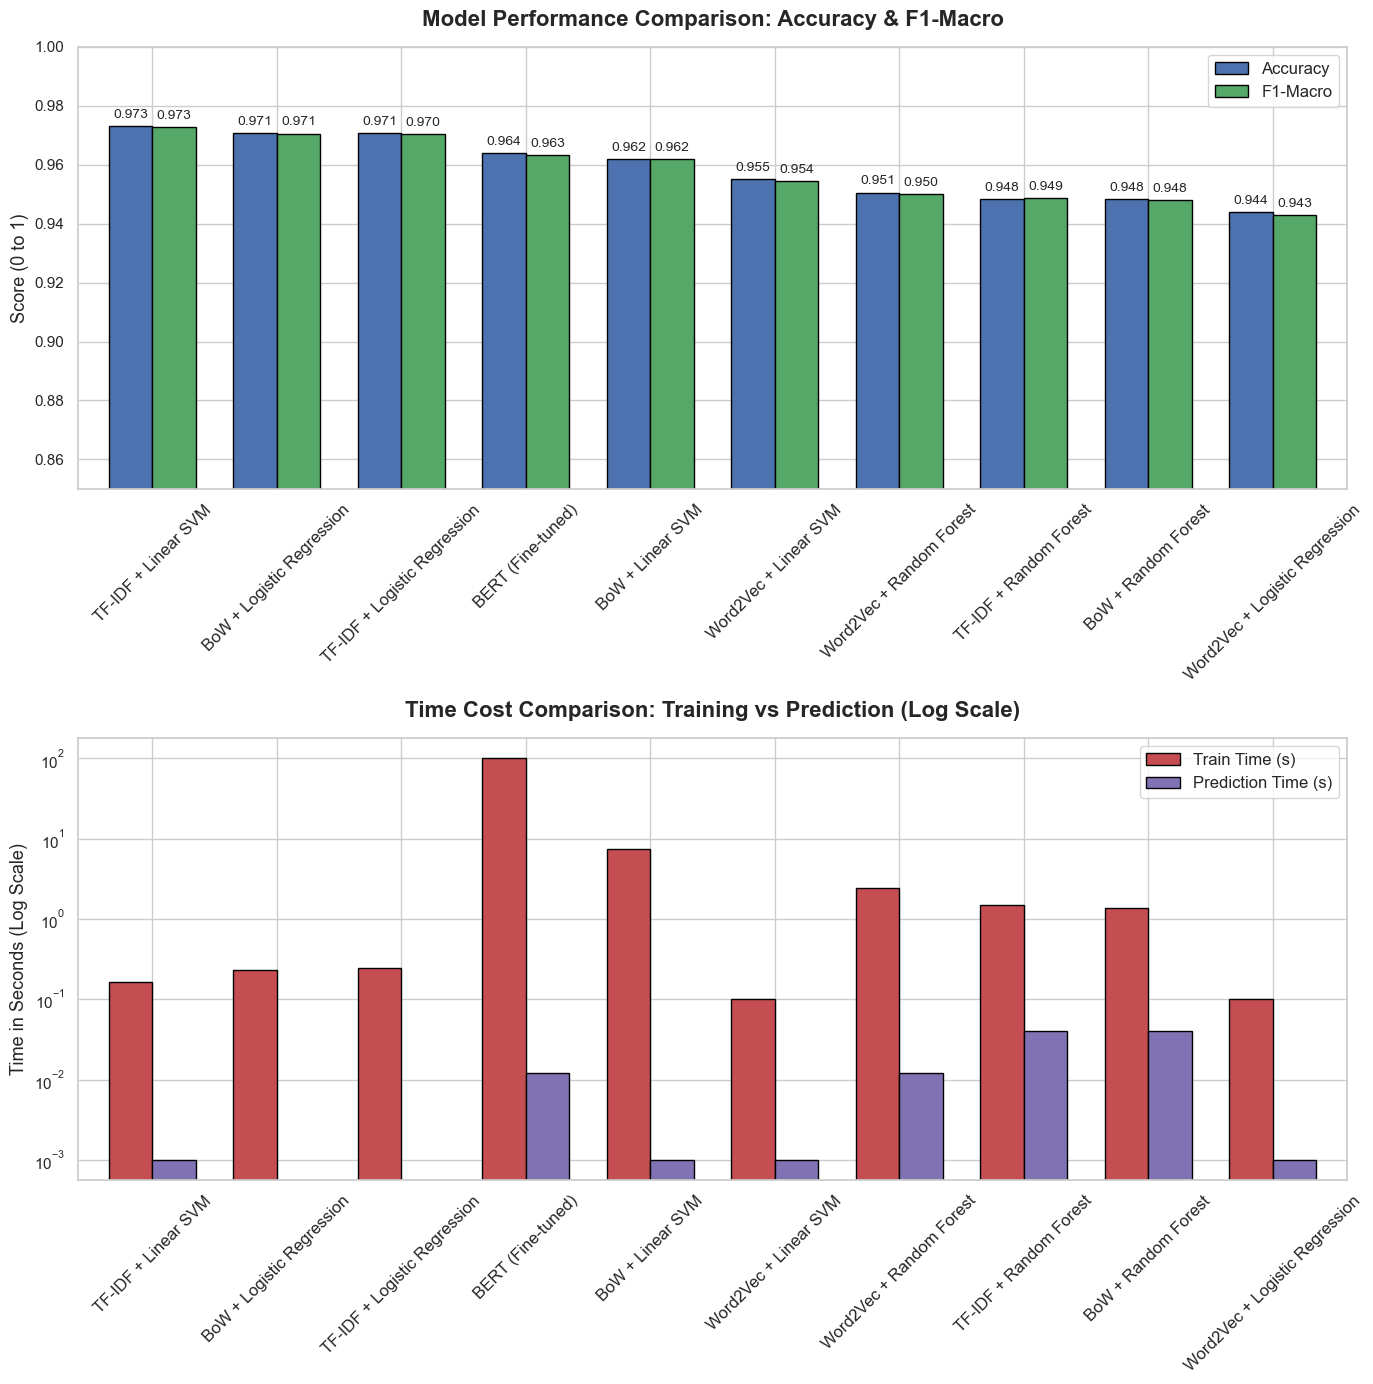

In [13]:
final_results = traditional_results_df.copy()

bert_row = pd.DataFrame({
    'Accuracy': [bert_results['eval_Accuracy']],
    'F1-Macro': [bert_results['eval_F1-Macro']],
    'Train Time (s)': [total_train_time], 
    'Prediction Time (s)': [pred_time]
}, index=['BERT (Fine-tuned)'])

final_results = pd.concat([final_results, bert_row])

final_results = final_results.sort_values(by='F1-Macro', ascending=False)

display(final_results)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

final_results[['Accuracy', 'F1-Macro']].plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#55A868'], edgecolor='black', width=0.7
)
axes[0].set_title('Model Performance Comparison: Accuracy & F1-Macro', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('Score (0 to 1)', fontsize=13)
axes[0].set_ylim(0.85, 1.0) 
axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].legend(loc='upper right', fontsize=12)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), 
                     textcoords='offset points', fontsize=10)

final_results[['Train Time (s)', 'Prediction Time (s)']].plot(
    kind='bar', ax=axes[1], color=['#C44E52', '#8172B3'], edgecolor='black', logy=True, width=0.7
)
axes[1].set_title('Time Cost Comparison: Training vs Prediction (Log Scale)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('Time in Seconds (Log Scale)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45, labelsize=12)
axes[1].legend(loc='upper right', fontsize=12)


plt.tight_layout()
plt.show()